In [38]:
from torch_snippets import *
from torchvision import transforms as T
from torch.nn import functional as F
from torchvision.models import vgg19

device = 'cuda' if torch.cuda.is_available() else 'cpu' #imports

In [39]:
preprocessamento = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    T.Lambda(lambda x: x.mul_(255))
])

posprocessamento = T.Compose([
    T.Lambda(lambda x: x.mul_(1./255)),
    T.Normalize(mean=[-0.485/0.229, -0.456/0.224,-0.406/0.225], std=[1/0.229,1/0.224,1/0.225]),
]) #funcoes pra formatar

In [40]:
imagem_estilo_bruta = Image.open('dados/monacatromerobritto-cke.webp').resize((512, 512)).convert('RGB')
imagem_conteudo_bruta = Image.open('dados/PR/dino_thunder.jpeg').resize((512, 512)).convert('RGB')

imagem_estilo = preprocessamento(imagem_estilo_bruta).to(device)[None]
imagem_conteudo = preprocessamento(imagem_conteudo_bruta).to(device)[None] #pega as imagens e formato

In [41]:
class MatrizGram(nn.Module):
    def forward(self, entrada):
        b, c, h, w = entrada.size() #pega as dimensoes da entrada 
        caracteristicas = entrada.view(b, c, h * w)
        matriz_g = caracteristicas @ caracteristicas.transpose(1, 2)
        matriz_g.div_(h * w)
        return matriz_g  #normaliza os valores achata a imagem

class ErroGramMSE(nn.Module):
    def forward(self, entrada, alvo): 
        erro = F.mse_loss(MatrizGram()(entrada), alvo)
        return erro #calcula o erro MSE

class ModeloVGG19(nn.Module):
    def __init__(self):
        super().__init__()
        camadas_vgg = list(vgg19(pretrained=True).features) #loda as camadas VGG
        self.camadas = nn.ModuleList(camadas_vgg).eval() #guarda em modo de teste
        
    def forward(self, x, camadas_escolhidas=[]):
        ordem = np.argsort(camadas_escolhidas) #da ordem de camada
        resultados_temp = [] 
        resultados = [] #resultados
        for indice, camada in enumerate(self.camadas): #vai na camada inteira
            x = camada(x) #coloca na camada
            if indice in camadas_escolhidas: 
                resultados_temp.append(x) #pega a saida da camada
        for o in ordem: 
            resultados.append(resultados_temp[o]) #organiza os resultados
        if camadas_escolhidas == []:
            return x #se n tiver camada so retorna x
        return resultados

In [42]:
modelo = ModeloVGG19().to(device) #colocando o modelo no device

In [43]:
imagem_otimizada = imagem_conteudo.data.clone() #copia imagem
imagem_otimizada.requires_grad = True

In [44]:
camadas_estilo = [0, 5, 10, 19, 28] 
camadas_conteudo = [21]
camadas_erro = camadas_estilo + camadas_conteudo #junta as camadas

In [45]:
funcoes_erro_estilo = []
for i in range(len(camadas_estilo)): #vai nas camadas de estilo
    funcoes_erro_estilo.append(ErroGramMSE().to(device)) #pega o erro

funcoes_erro_conteudo = []
for i in range(len(camadas_conteudo)):
    funcoes_erro_conteudo.append(nn.MSELoss().to(device)) #vai nas camadas da iamgem do conteudo e pega o erro

funcoes_erro = funcoes_erro_estilo + funcoes_erro_conteudo

In [46]:
pesos_estilo = []
para_dividir = [64, 128, 256, 512, 512] #valores pro calculo
for n in para_dividir: #pra cada numero 
    pesos_estilo.append(1000 / (n * n)) #pega a proporcao

pesos_conteudo = [1] 
pesos = pesos_estilo + pesos_conteudo #pesos

In [47]:
alvos_estilo = []
resultados_estilo = modelo(imagem_estilo, camadas_estilo)
for resultado in resultados_estilo:
    alvos_estilo.append(MatrizGram()(resultado).detach())

alvos_conteudo = []
resultados_conteudo = modelo(imagem_conteudo, camadas_conteudo)
for resultado in resultados_conteudo:
    alvos_conteudo.append(resultado.detach())

alvos = alvos_estilo + alvos_conteudo

In [52]:
interacoes_maximas = 1000
otimizador = optim.LBFGS([imagem_otimizada])
registro = Report(interacoes_maximas)

In [53]:
interacoes = 0
while interacoes < interacoes_maximas:
    def closure():
        global interacoes
        interacoes = interacoes + 1
        otimizador.zero_grad()
        saida = modelo(imagem_otimizada, camadas_erro)
        erros_camada = []
        for indice, resultado in enumerate(saida):
            erro_calculado = pesos[indice] * funcoes_erro[indice](resultado, alvos[indice])
            erros_camada.append(erro_calculado)
        erro_total = sum(erros_camada)
        erro_total.backward()
        registro.record(pos=interacoes, loss=erro_total, end='\r')
        return erro_total
    
    otimizador.step(closure)

EPOCH: 1000.000  loss: 1865084.625  (167.09s - 0.00s remaining)

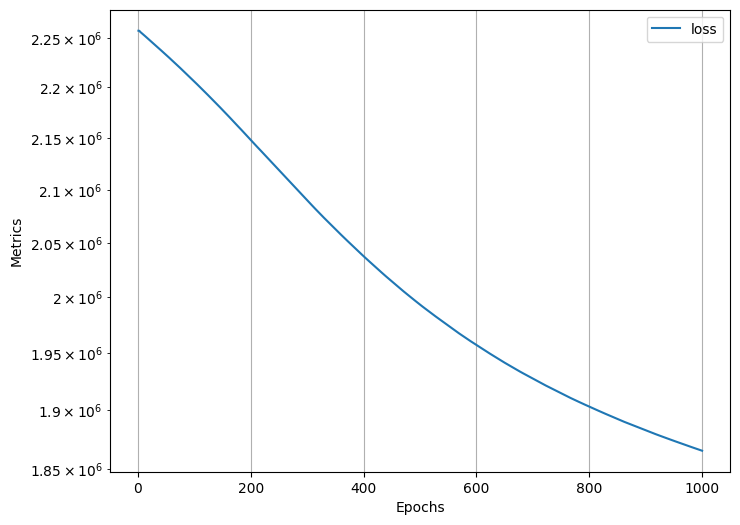

In [54]:
registro.plot(log=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.66179734..1.6745524].


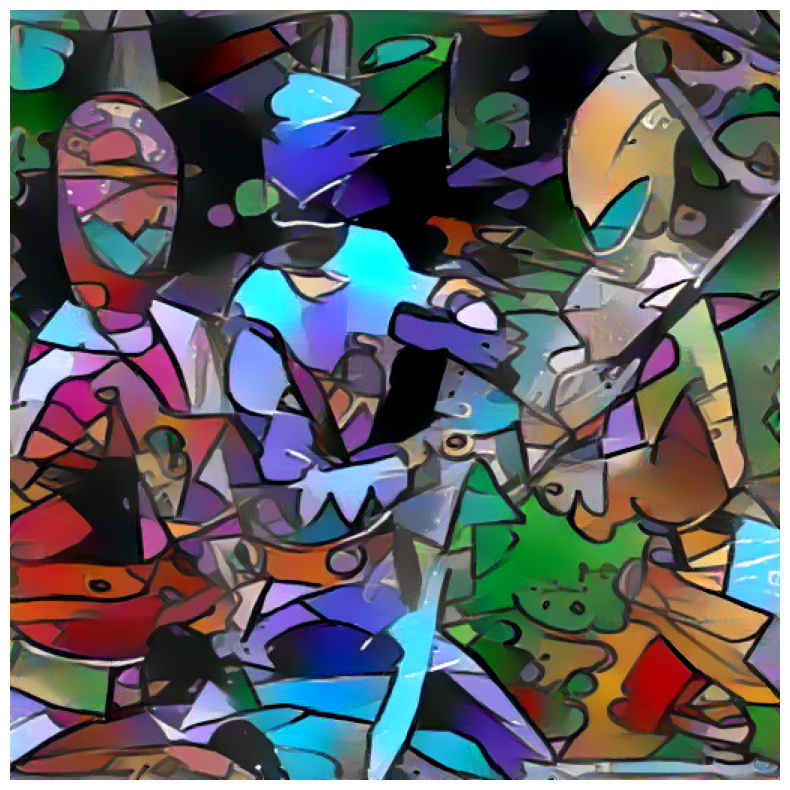

In [55]:
mostrar_imagem = posprocessamento(imagem_otimizada[0].detach().cpu())
show(mostrar_imagem)

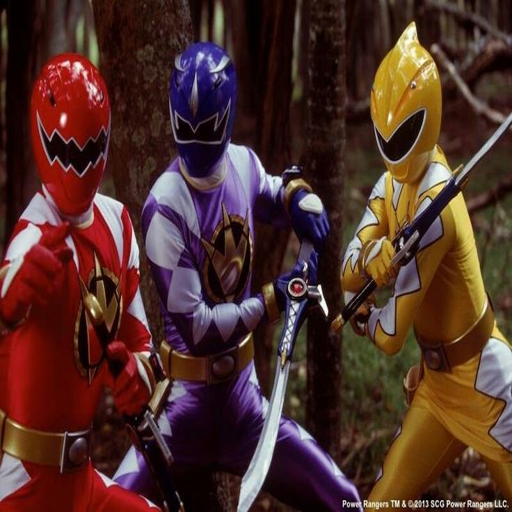

In [35]:
imagem_conteudo_bruta